# BirdBase × AVONET — Data Merging & Feature Engineering

This notebook merges two bird trait databases — **AVONET** (morphological measurements) and **BirdBase** (ecology, diet, elevation, nest type) — into a single combined dataset keyed on `avibase_id`.

**Workflow overview:**
1. Load raw datasets
2. Cast numeric columns (both sources have MISSING strings and mixed types)
3. Harmonise categorical vocabularies so conflicting columns are comparable
4. Resolve BirdBase duplicates (67 species appear twice)
5. Rename columns to clear, readable names
6. Outer-merge on `avibase_id` and add provenance flags

## 1 · Setup

In [3]:
import pandas as pd
import numpy as np
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

BASE = Path("../data/raw")

# ── Display settings ──────────────────────────────────────────────────────────
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1200)
pd.set_option("display.max_colwidth", 100)

# Suppress mixed-type warnings that arise from messy raw data
warnings.filterwarnings("ignore")

## 2 · Load Raw Data

In [4]:
birdbase = pd.read_csv(BASE / "BirdBase/birdbase_uncleaned_final_dataset.csv")
avonet   = pd.read_csv(BASE / "Avonet/avonet_uncleaned_final_dataset.csv")

print(f"AVONET   : {avonet.shape[0]:,} rows × {avonet.shape[1]} cols")
print(f"BirdBase : {birdbase.shape[0]:,} rows × {birdbase.shape[1]} cols")

AVONET   : 11,237 rows × 48 cols
BirdBase : 11,412 rows × 36 cols


In [5]:
avonet.head()

,avibase_id,beak_culmen_avg,beak_culmen_avg_m,beak_culmen_avg_f,beak_nares_avg,beak_nares_avg_m,beak_nares_avg_f,beak_width_avg,beak_width_avg_m,beak_width_avg_f,beak_depth_avg,beak_depth_avg_m,beak_depth_avg_f,tarsus_avg,tarsus_avg_m,tarsus_avg_f,wing_len_avg,wing_len_avg_m,wing_len_avg_f,kipps_avg,kipps_avg_m,kipps_avg_f,secondary_avg,secondary_avg_m,secondary_avg_f,hwi_avg,hwi_avg_m,hwi_avg_f,tail_avg,tail_avg_m,tail_avg_f,total_individuals,female_count,male_count,mass_avg,mass_source,inference,habitat,habitat_density,migration,trophic_level,trophic_niche,lifestyle,lat_min,lat_max,lat_centroid,lon_centroid,range_size
0,AVIBASE-B3F5E5E2,13.00000,12.13333,14.30000,9.50000,9.00000,10.00000,1.18000,1.23333,1.10000,1.68000,1.63333,1.75000,6.34000,5.53333,7.55000,47.00000,48.33333,45.00000,30.50000,30.50000,30.50000,15.50000,16.50000,14.50000,66.35000,64.90000,67.80000,29.40000,30.00000,28.50000,5.00000,2.00000,3.00000,2.70000,Dunning,NO,Forest,2.00000,1.00000,Herbivore,Nectarivore,Aerial,12.78000,19.77000,15.29000,-89.79000,144610.40000
1,AVIBASE-684016CB,8.98000,9.06667,8.85000,4.90000,4.90000,4.90000,2.74000,2.66667,2.85000,2.34000,2.36667,2.30000,15.28000,15.43333,15.05000,43.40000,44.16667,42.25000,5.70000,5.80000,5.60000,37.30000,37.95000,36.65000,13.27500,13.25000,13.30000,38.70000,38.83333,38.50000,5.00000,2.00000,3.00000,4.80000,Dunning,NO,Forest,1.00000,1.00000,Carnivore,Invertivore,Insessorial,14.97000,31.56000,24.78000,105.57000,1704650.60000
2,AVIBASE-0FD03AFF,8.95000,8.80000,9.00000,4.67500,4.50000,4.73333,2.60000,2.70000,2.56667,2.32500,2.50000,2.26667,16.52500,16.80000,16.43333,47.12500,48.00000,46.83333,7.60000,8.40000,7.33333,39.52500,39.60000,39.50000,16.12500,17.50000,15.66667,47.50000,48.00000,47.33333,4.00000,3.00000,1.00000,4.70000,Dunning,NO,Forest,1.00000,1.00000,Carnivore,Invertivore,Insessorial,20.19000,31.12000,26.70000,95.58000,909217.05000
3,AVIBASE-A8F5D21F,12.32000,12.26667,12.40000,7.37500,7.35000,7.40000,3.12000,3.10000,3.15000,2.84000,2.96667,2.65000,16.58000,16.76667,16.30000,51.20000,52.33333,49.50000,6.47500,6.70000,6.25000,44.52500,45.80000,43.25000,12.70000,12.75000,12.65000,42.40000,44.33333,39.50000,5.00000,2.00000,3.00000,6.50000,Dunning,NO,Shrubland,1.00000,1.00000,Carnivore,Invertivore,Insessorial,-8.11000,28.81000,9.89000,105.20000,2493437.47000
4,AVIBASE-50A42775,37.11667,38.88333,35.35000,16.62500,17.20000,16.05000,9.26250,9.27500,9.25000,10.25000,11.30000,9.20000,65.81667,68.50000,63.13333,337.18182,343.40000,332.00000,52.50000,52.50000,52.50000,283.10000,291.50000,277.50000,15.66000,15.30000,15.90000,290.37500,300.33333,280.41667,12.00000,6.00000,6.00000,1405.10000,Dunning,NO,Forest,1.00000,1.00000,Herbivore,Frugivore,Insessorial,-13.43000,11.15000,-2.79000,-75.23000,139314.36000


In [6]:
birdbase.head()

,avibase_id,species_latin_key,order,family,genus,mass_female_min,mass_female_max,mass_male_min,mass_male_max,mass_unsexed_min,mass_unsexed_max,mass_avg,elev_min,elev_norm_min,elev_range,elev_norm_max,elev_max,habitat_primary,diet_primary,diet_invertebrate,diet_fruit,diet_nectar,diet_seed,diet_vertebrate,diet_fish,diet_scavenge,diet_plant,diet_mushroom,diet_sum,nest_type,flightless,migratory,altitudinal_migrant,irregular_migrant,dispersive,sedentary
0,AVIBASE-2247CB05,Struthio camelus,Struthioniformes,Struthionidae,Struthio,90000.00000,110000.00000,100000.00000,156000.00000,86000.00000,145000.00000,114500.00000,MISSING,0,3000.00000,3000,MISSING,Savanna,Herbivore,1,0,0,3,1,0,0,5,0,10.0,SC,Yes,MISSING,MISSING,1.00000,MISSING,1.00000
1,AVIBASE-40329BB6,Struthio molybdophanes,Struthioniformes,Struthionidae,Struthio,100000.00000,MISSING,115000.00000,MISSING,105500.00000,111000.00000,107875.00000,MISSING,0,3000.00000,3000,MISSING,Plains,Herbivore,1,0,0,3,1,0,0,5,0,10.0,SC,Yes,MISSING,MISSING,1.00000,MISSING,1.00000
2,AVIBASE-00986B24,Rhea americana,Rheiformes,Rheidae,Rhea,MISSING,MISSING,MISSING,MISSING,10500.00000,40000.00000,25250.00000,MISSING,0,1200.00000,1200,MISSING,Savanna,Plant,0.01,0.06,0,0.89,0.01,0,0,9.01,0.02,10.0,SC,Yes,MISSING,MISSING,MISSING,MISSING,1.00000
3,AVIBASE-BA52A675,Rhea pennata,Rheiformes,Rheidae,Rhea,MISSING,MISSING,19100.00000,28600.00000,15000.00000,25000.00000,21925.00000,MISSING,0,4500.00000,4500,MISSING,Plains,Plant,T,T,0,0.6,T,0,0,9.4,0,10.0,SC,Yes,MISSING,1.00000,MISSING,MISSING,1.00000
4,AVIBASE-6BA55EF0,Apteryx australis,Apterygiformes,Apterygidae,Apteryx,2060.00000,3850.00000,1440.00000,3060.00000,MISSING,MISSING,2602.50000,MISSING,0,1500.00000,1500,MISSING,Forest,Invertebrate,10,T,0,T,0,0,0,T,0,10.0,"BU,CV",Yes,MISSING,MISSING,MISSING,MISSING,1.00000


## 3 · AVONET — Numeric Type Casting

All morphometric and geographic columns were read as `object` because some rows contain
commas or whitespace.  We strip those and coerce to `float64`; anything unparseable becomes `NaN`.

In [7]:
AVONET_NUMERIC_COLS = [
    'beak_culmen_avg', 'beak_culmen_avg_m', 'beak_culmen_avg_f',
    'beak_nares_avg',  'beak_nares_avg_m',  'beak_nares_avg_f',
    'beak_width_avg',  'beak_width_avg_m',  'beak_width_avg_f',
    'beak_depth_avg',  'beak_depth_avg_m',  'beak_depth_avg_f',
    'tarsus_avg',      'tarsus_avg_m',      'tarsus_avg_f',
    'wing_len_avg',    'wing_len_avg_m',    'wing_len_avg_f',
    'kipps_avg',       'kipps_avg_m',       'kipps_avg_f',
    'secondary_avg',   'secondary_avg_m',   'secondary_avg_f',
    'hwi_avg',         'hwi_avg_m',         'hwi_avg_f',
    'tail_avg',        'tail_avg_m',        'tail_avg_f',
    'total_individuals', 'female_count', 'male_count',
    'mass_avg', 'habitat_density', 'migration',
    'lat_min', 'lat_max', 'lat_centroid', 'lon_centroid', 'range_size',
]

for col in AVONET_NUMERIC_COLS:
    avonet[col] = pd.to_numeric(
        avonet[col].astype(str).str.replace(",", "").str.strip(),
        errors="coerce"
    )

avonet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11237 entries, 0 to 11236
Data columns (total 48 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   avibase_id         11237 non-null  object 
 1   beak_culmen_avg    10847 non-null  float64
 2   beak_culmen_avg_m  10253 non-null  float64
 3   beak_culmen_avg_f  9623 non-null   float64
 4   beak_nares_avg     10696 non-null  float64
 5   beak_nares_avg_m   9986 non-null   float64
 6   beak_nares_avg_f   9510 non-null   float64
 7   beak_width_avg     10837 non-null  float64
 8   beak_width_avg_m   10289 non-null  float64
 9   beak_width_avg_f   9624 non-null   float64
 10  beak_depth_avg     10834 non-null  float64
 11  beak_depth_avg_m   10295 non-null  float64
 12  beak_depth_avg_f   9675 non-null   float64
 13  tarsus_avg         10862 non-null  float64
 14  tarsus_avg_m       10326 non-null  float64
 15  tarsus_avg_f       9726 non-null   float64
 16  wing_len_avg       108

## 4 · BirdBase — Cleaning & Feature Engineering

BirdBase stores missing values as the string `"MISSING"` rather than `NaN`.
We normalise these first, then work through each feature group.

### 4.1 · Body Mass

Both datasets record body mass in grams.  BirdBase `mass_avg` is stored as `object`
due to the `"MISSING"` sentinel — we cast it to numeric.

In [8]:
birdbase["mass_avg"] = pd.to_numeric(
    birdbase["mass_avg"].astype(str).str.replace(",", "").str.strip(),
    errors="coerce"
)

print(f"dtype  : {birdbase['mass_avg'].dtype}")
print(f"nulls  : {birdbase['mass_avg'].isna().sum():,}")
print()
print(birdbase["mass_avg"].describe())

dtype  : float64
nulls  : 924

count     10488.000000
mean        282.153043
std        1957.335319
min           2.090000
25%          15.000000
50%          35.566665
75%         127.000000
max      114500.000000
Name: mass_avg, dtype: float64


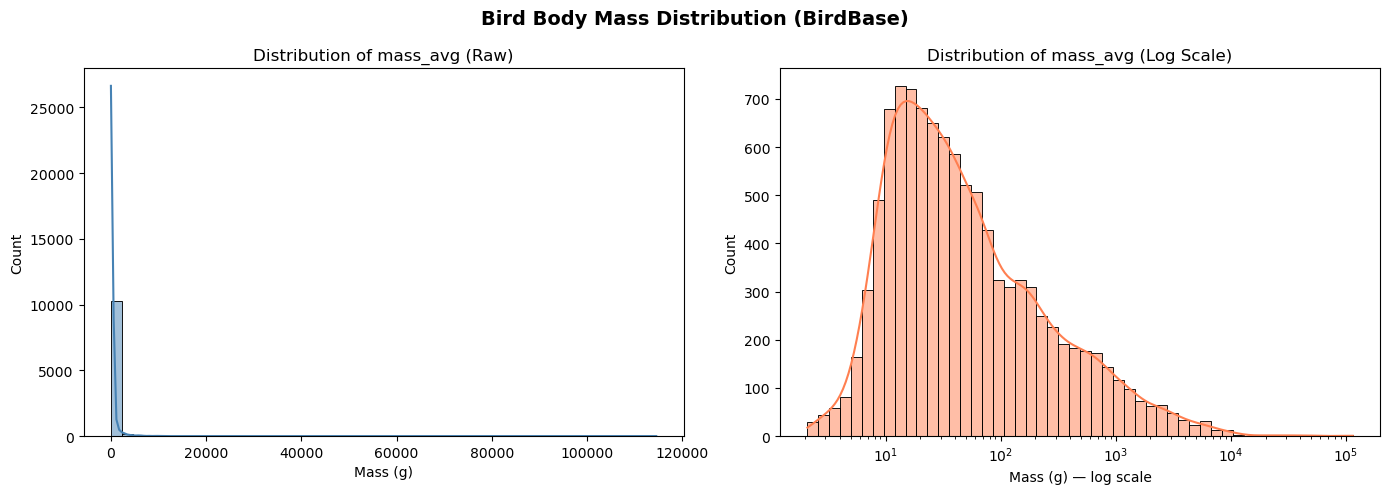

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(birdbase["mass_avg"].dropna(), bins=50, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution of mass_avg (Raw)")
axes[0].set_xlabel("Mass (g)")
axes[0].set_ylabel("Count")

sns.histplot(birdbase["mass_avg"].dropna(), bins=50, kde=True, ax=axes[1], color="coral", log_scale=True)
axes[1].set_title("Distribution of mass_avg (Log Scale)")
axes[1].set_xlabel("Mass (g) — log scale")
axes[1].set_ylabel("Count")

plt.suptitle("Bird Body Mass Distribution (BirdBase)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

Body mass is strongly right-skewed (a few very heavy species like ostriches pull the mean far above the median).  Log-scale is the appropriate axis for downstream analysis.

### 4.2 · Primary Diet — Vocabulary Harmonisation

BirdBase uses fine-grained diet labels (e.g. `Invertebrate`, `Fish`, `Fruit`) while AVONET uses
broad trophic levels (`Carnivore`, `Herbivore`, `Omnivore`, `Scavenger`).
We map BirdBase's labels to the same four-class schema so the two sources can be compared.

In [10]:
print("BirdBase diet_primary values:")
print(birdbase["diet_primary"].value_counts())
print()
print("AVONET trophic_level values:")
print(avonet["trophic_level"].value_counts())

BirdBase diet_primary values:
diet_primary
Invertebrate      6109
Fruit             1316
Omnivore          1081
Seed               849
Nectar             589
Herbivore          422
Vertebrate         332
Fish               283
Carnivore          210
Plant              156
Scavenger           29
No Information      27
Beeswax              7
Ovivore              2
Name: count, dtype: int64

AVONET trophic_level values:
trophic_level
Carnivore    5914
Herbivore    2973
Omnivore     1749
MISSING       581
Scavenger      20
Name: count, dtype: int64


In [11]:
diet_mapping = {
    # → Carnivore
    "Invertebrate": "Carnivore",
    "Vertebrate":   "Carnivore",
    "Fish":         "Carnivore",
    "Carnivore":    "Carnivore",
    "Ovivore":      "Carnivore",
    # → Herbivore
    "Fruit":        "Herbivore",
    "Seed":         "Herbivore",
    "Nectar":       "Herbivore",
    "Herbivore":    "Herbivore",
    "Plant":        "Herbivore",
    "Beeswax":      "Herbivore",
    # → Omnivore
    "Omnivore":     "Omnivore",
    # → Scavenger
    "Scavenger":    "Scavenger",
    # → MISSING
    "No Information": "MISSING",
}

birdbase["diet_primary"] = birdbase["diet_primary"].map(diet_mapping).fillna("MISSING")

print("BirdBase diet_primary after harmonisation:")
print(birdbase["diet_primary"].value_counts())

BirdBase diet_primary after harmonisation:
diet_primary
Carnivore    6936
Herbivore    3339
Omnivore     1081
Scavenger      29
MISSING        27
Name: count, dtype: int64


### 4.3 · Trophic Niche — Derived from Diet Proportions

BirdBase provides quantitative diet proportions across 9 food categories (each out of 10).
We derive a `trophic_niche` label that matches AVONET's taxonomy by taking the
**dominant diet column**:
- Max proportion > 5 → that category's niche label
- Max proportion ≤ 5 → `Omnivore` (no clear dominant)
- All NaN / all zero → `MISSING`

In [12]:
print("AVONET trophic_niche values:")
print(avonet["trophic_niche"].value_counts())

AVONET trophic_niche values:
trophic_niche
Invertivore              5127
Omnivore                 1863
Frugivore                1164
Aquatic predator          780
Granivore                 681
MISSING                   586
Nectarivore               537
Vertivore                 301
Herbivore terrestrial      95
Herbivore aquatic          81
Scavenger                  22
Name: count, dtype: int64


In [13]:
DIET_PROPORTION_COLS = [
    'diet_invertebrate', 'diet_fruit', 'diet_nectar', 'diet_seed',
    'diet_vertebrate', 'diet_fish', 'diet_scavenge', 'diet_plant', 'diet_mushroom'
]

# Cast proportion columns to numeric (contain 'T' traces and MISSING strings)
for col in DIET_PROPORTION_COLS + ['diet_sum']:
    birdbase[col] = pd.to_numeric(
        birdbase[col].astype(str).str.replace(",", "").str.strip(),
        errors="coerce"
    )

birdbase["diet_invertebrate"].describe()

count    11063.000000
mean         5.856995
std          3.714126
min          0.000000
25%          2.000000
50%          6.000000
75%         10.000000
max         10.000000
Name: diet_invertebrate, dtype: float64

In [14]:
DOMINANT_TO_NICHE = {
    'diet_invertebrate': 'Invertivore',
    'diet_fruit':        'Frugivore',
    'diet_nectar':       'Nectarivore',
    'diet_seed':         'Granivore',
    'diet_vertebrate':   'Vertivore',
    'diet_fish':         'Aquatic predator',
    'diet_scavenge':     'Scavenger',
    'diet_plant':        'Herbivore terrestrial',
    'diet_mushroom':     'Herbivore terrestrial',
}

def assign_trophic_niche(row):
    values = row[DIET_PROPORTION_COLS]
    if values.isna().all() or values.sum() == 0:
        return 'MISSING'
    max_val = values.max()
    if max_val == 0:
        return 'MISSING'
    elif max_val <= 5:
        return 'Omnivore'
    return DOMINANT_TO_NICHE[values.idxmax()]

birdbase['trophic_niche'] = birdbase.apply(assign_trophic_niche, axis=1)

print("BirdBase trophic_niche after derivation:")
print(birdbase['trophic_niche'].value_counts())

BirdBase trophic_niche after derivation:
trophic_niche
Invertivore              6112
Omnivore                 1700
Frugivore                1318
Granivore                 852
Nectarivore               589
Vertivore                 332
Aquatic predator          285
Herbivore terrestrial     168
Scavenger                  29
MISSING                    27
Name: count, dtype: int64


### 4.4 · Habitat — Vocabulary Harmonisation

BirdBase uses 14 habitat labels; AVONET uses 12.  We map BirdBase labels to AVONET's schema
so the `_BB` and main habitat columns are directly comparable.

In [15]:
print("BirdBase habitat_primary:")
print(birdbase["habitat_primary"].value_counts())
print()
print("AVONET habitat:")
print(avonet["habitat"].value_counts())

BirdBase habitat_primary:
habitat_primary
Forest        6568
Shrub         1138
Woodland       959
Grassland      729
Wetland        633
Coastal        281
Sea            243
Savanna        240
Riparian       227
Rocky          157
Plains         119
Artificial      58
Desert          54
Bamboo           6
Name: count, dtype: int64

AVONET habitat:
habitat
Forest            6097
Shrubland         1341
Woodland           921
Grassland          782
MISSING            672
Wetland            635
Marine             266
Rock               123
Human Modified     118
Coastal            108
Riverine           104
Desert              70
Name: count, dtype: int64


In [16]:
habitat_mapping = {
    'Forest':    'Forest',
    'Shrub':     'Shrubland',
    'Woodland':  'Woodland',
    'Grassland': 'Grassland',
    'Wetland':   'Wetland',
    'Coastal':   'Coastal',
    'Sea':       'Marine',
    'Savanna':   'Grassland',   # Savanna mapped to Grassland (open biome)
    'Riparian':  'Riverine',
    'Rocky':     'Rock',
    'Plains':    'Grassland',   # Plains mapped to Grassland (open biome)
    'Artificial':'Human Modified',
    'Desert':    'Desert',
    'Bamboo':    'Forest',      # Bamboo forests treated as Forest
}

birdbase['habitat_primary'] = birdbase['habitat_primary'].map(habitat_mapping).fillna('MISSING')

print("BirdBase habitat_primary after harmonisation:")
print(birdbase['habitat_primary'].value_counts())

BirdBase habitat_primary after harmonisation:
habitat_primary
Forest            6574
Shrubland         1138
Grassland         1088
Woodland           959
Wetland            633
Coastal            281
Marine             243
Riverine           227
Rock               157
Human Modified      58
Desert              54
Name: count, dtype: int64


### 4.5 · Migration Columns — Decision to Drop

BirdBase encodes migration behaviour across five binary columns
(`migratory`, `altitudinal_migrant`, `irregular_migrant`, `dispersive`, `sedentary`).
Missing-value analysis shows that most of these columns are extremely sparse:

In [17]:
migration_cols = ['migratory', 'altitudinal_migrant', 'irregular_migrant', 'dispersive', 'sedentary']

for col in migration_cols:
    n_missing = (birdbase[col].astype(str) == 'MISSING').sum() + birdbase[col].isna().sum()
    pct = n_missing / len(birdbase) * 100
    print(f"{col:<25} {n_missing:>6,} missing  ({pct:.1f}%)")

migratory                  9,121 missing  (79.9%)
altitudinal_migrant        9,921 missing  (86.9%)
irregular_migrant          9,065 missing  (79.4%)
dispersive                10,834 missing  (94.9%)
sedentary                  2,395 missing  (21.0%)


**Conclusion:** These columns are too sparse (75–95 % missing) to be useful as features.
AVONET already provides a clean numeric `migration` score (1 = sedentary, 3 = migratory),
so we drop the BirdBase migration columns entirely.

### 4.6 · Elevation Columns — Missing-Value Audit

BirdBase records elevation using five columns:
`elev_min`, `elev_norm_min`, `elev_range`, `elev_norm_max`, `elev_max`.
We audit them to decide which to keep.

In [18]:
elev_cols = ['elev_min', 'elev_norm_min', 'elev_range', 'elev_norm_max', 'elev_max']

missing_values_sentinel = ["nan", "NaN", "null", "NULL", "NA", "N/A", "MISSING", "", " "]
df_str = birdbase.astype(str)

for col in elev_cols:
    missing_mask = birdbase[col].isna() | df_str[col].isin(missing_values_sentinel)
    n = missing_mask.sum()
    pct = n / len(birdbase) * 100
    print(f"{col:<20} {n:>6,} missing  ({pct:.1f}%)")

elev_min              9,802 missing  (85.9%)
elev_norm_min           349 missing  (3.1%)
elev_range              685 missing  (6.0%)
elev_norm_max           390 missing  (3.4%)
elev_max              8,521 missing  (74.7%)


**Conclusion:**
- `elev_min` (86 % missing) and `elev_max` (75 % missing) are too sparse to be useful — **dropped**.
- `elev_norm_min` and `elev_norm_max` are better covered and represent
  the normalised lower/upper bounds of a species' elevation range — **kept**.
- `elev_range` (6 % missing) is the most complete elevation feature — **kept**.

### 4.7 · Full Missing-Value Summary (BirdBase)

In [19]:
df_str = birdbase.astype(str)
summary = {}
for col in birdbase.columns:
    missing_mask = birdbase[col].isna() | df_str[col].isin(missing_values_sentinel)
    summary[col] = missing_mask.sum()

pd.DataFrame.from_dict(summary, orient='index', columns=['missing_count']) \
  .sort_values('missing_count', ascending=False)

,missing_count
dispersive,10834
altitudinal_migrant,9921
elev_min,9802
migratory,9121
irregular_migrant,9065
elev_max,8521
mass_female_max,7281
mass_male_max,6900
mass_female_min,5503
mass_male_min,5497


### 4.8 · Drop Sparse & Redundant Columns

Based on the missing-value audit above, we drop:
- **Mass range columns** (`mass_female_min/max`, `mass_male_min/max`, `mass_unsexed_min/max`) — `mass_avg` is already the usable summary
- **Raw elevation bounds** (`elev_min`, `elev_max`) — too sparse; normalised versions retained
- **Individual diet proportions** — we've already derived `trophic_niche` from them
- **Migration binary columns** — too sparse; AVONET already has `migration`
- **Taxonomy columns** (`order`, `family`, `genus`, `species_latin_key`) — duplicated in other sources

In [20]:
DROP_COLS = [
    # Mass range (redundant given mass_avg)
    'mass_female_min', 'mass_female_max',
    'mass_male_min',   'mass_male_max',
    'mass_unsexed_min','mass_unsexed_max',
    # Elevation (too sparse)
    'elev_min', 'elev_max',
    # Diet proportions (trophic_niche already derived)
    'diet_invertebrate', 'diet_fruit', 'diet_nectar', 'diet_seed',
    'diet_vertebrate', 'diet_fish', 'diet_scavenge', 'diet_plant',
    'diet_mushroom', 'diet_sum',
    # Migration (too sparse)
    'migratory', 'altitudinal_migrant', 'irregular_migrant', 'dispersive', 'sedentary',
    # Taxonomy (available elsewhere)
    'order', 'family', 'genus', 'species_latin_key',
]

birdbase.drop(columns=DROP_COLS, inplace=True)

print(f"BirdBase columns remaining: {list(birdbase.columns)}")

BirdBase columns remaining: ['avibase_id', 'mass_avg', 'elev_norm_min', 'elev_range', 'elev_norm_max', 'habitat_primary', 'diet_primary', 'nest_type', 'flightless', 'trophic_niche']


## 5 · Column Renaming

Both datasets are renamed to clear, readable names before merging.
Columns that exist in **both** datasets (mass, habitat, trophic niche) get `_BB` suffixes
on the BirdBase side so both versions are preserved in the combined dataset.

In [21]:
AVONET_RENAME = {
    # Beak measurements
    'beak_culmen_avg':   'beak_culmen',       'beak_culmen_avg_m': 'beak_culmen_m',      'beak_culmen_avg_f': 'beak_culmen_f',
    'beak_nares_avg':    'beak_nares',         'beak_nares_avg_m':  'beak_nares_m',       'beak_nares_avg_f':  'beak_nares_f',
    'beak_width_avg':    'beak_width',         'beak_width_avg_m':  'beak_width_m',       'beak_width_avg_f':  'beak_width_f',
    'beak_depth_avg':    'beak_depth',         'beak_depth_avg_m':  'beak_depth_m',       'beak_depth_avg_f':  'beak_depth_f',
    # Body measurements
    'tarsus_avg':        'tarsus',             'tarsus_avg_m':      'tarsus_m',           'tarsus_avg_f':      'tarsus_f',
    'wing_len_avg':      'wing_len',           'wing_len_avg_m':    'wing_len_m',         'wing_len_avg_f':    'wing_len_f',
    'kipps_avg':         'kipps',              'kipps_avg_m':       'kipps_m',            'kipps_avg_f':       'kipps_f',
    'secondary_avg':     'secondary',          'secondary_avg_m':   'secondary_m',        'secondary_avg_f':   'secondary_f',
    'hwi_avg':           'hand_wing_index',    'hwi_avg_m':         'hand_wing_index_m',  'hwi_avg_f':         'hand_wing_index_f',
    'tail_avg':          'tail_len',           'tail_avg_m':        'tail_len_m',         'tail_avg_f':        'tail_len_f',
    # Sample info
    'total_individuals': 'sample_size',
    'female_count':      'sample_size_f',
    'male_count':        'sample_size_m',
    # Ecology / taxonomy
    'mass_avg':          'mass',
    'mass_source':       'mass_source',
    'habitat':           'habitat',
    'habitat_density':   'habitat_density',
    'trophic_level':     'primary_diet',
    'trophic_niche':     'trophic_niche',
    # Geography
    'lat_centroid':      'lat_centroid',
    'lon_centroid':      'lon_centroid',
    'range_size':        'range_size',
    # unchanged: avibase_id, inference, migration, lifestyle, lat_min, lat_max
}

BIRDBASE_RENAME = {
    'mass_avg':        'mass_BB',           # conflict → _BB suffix
    'elev_norm_min':   'elevation_min_BB',
    'elev_range':      'elevation_range_BB',
    'elev_norm_max':   'elevation_max_BB',
    'habitat_primary': 'habitat_BB',        # conflict → _BB suffix
    'diet_primary':    'primary_diet_BB',
    'nest_type':       'nest_type_BB',
    'flightless':      'flightless_BB',
    'trophic_niche':   'trophic_niche_BB',  # conflict → _BB suffix
    # unchanged: avibase_id
}

avonet   = avonet.rename(columns=AVONET_RENAME)
birdbase = birdbase.rename(columns=BIRDBASE_RENAME)

print("AVONET columns   :", list(avonet.columns))
print()
print("BirdBase columns :", list(birdbase.columns))

AVONET columns   : ['avibase_id', 'beak_culmen', 'beak_culmen_m', 'beak_culmen_f', 'beak_nares', 'beak_nares_m', 'beak_nares_f', 'beak_width', 'beak_width_m', 'beak_width_f', 'beak_depth', 'beak_depth_m', 'beak_depth_f', 'tarsus', 'tarsus_m', 'tarsus_f', 'wing_len', 'wing_len_m', 'wing_len_f', 'kipps', 'kipps_m', 'kipps_f', 'secondary', 'secondary_m', 'secondary_f', 'hand_wing_index', 'hand_wing_index_m', 'hand_wing_index_f', 'tail_len', 'tail_len_m', 'tail_len_f', 'sample_size', 'sample_size_f', 'sample_size_m', 'mass', 'mass_source', 'inference', 'habitat', 'habitat_density', 'migration', 'primary_diet', 'trophic_niche', 'lifestyle', 'lat_min', 'lat_max', 'lat_centroid', 'lon_centroid', 'range_size']

BirdBase columns : ['avibase_id', 'mass_BB', 'elevation_min_BB', 'elevation_range_BB', 'elevation_max_BB', 'habitat_BB', 'primary_diet_BB', 'nest_type_BB', 'flightless_BB', 'trophic_niche_BB']


## 6 · Resolve BirdBase Duplicates

BirdBase has 11,412 rows but only 11,345 unique `avibase_id` values — 67 species appear
more than once (different measurements from different source records).

**Resolution strategy:**
- **Numeric columns** → mean of all valid (non-null) values
- **Categorical columns** → first non-null value

In [22]:
# Inspect duplicates
dupes = birdbase[birdbase.duplicated(subset='avibase_id', keep=False)]
print(f"Duplicate rows     : {len(dupes)}")
print(f"Duplicate IDs      : {dupes['avibase_id'].nunique()}")
print()
dupes.sort_values('avibase_id').head(10)

Duplicate rows     : 134
Duplicate IDs      : 67



,avibase_id,mass_BB,elevation_min_BB,elevation_range_BB,elevation_max_BB,habitat_BB,primary_diet_BB,nest_type_BB,flightless_BB,trophic_niche_BB
6738,AVIBASE-0037A14F,11.87500,500,2000.00000,2500,Forest,Carnivore,HC,No,Invertivore
6739,AVIBASE-0037A14F,11.75000,1000,2000.00000,3000,Forest,Carnivore,HC,No,Invertivore
3622,AVIBASE-012084A9,45.00000,L,MISSING,1850,Forest,Carnivore,CV,No,Invertivore
3621,AVIBASE-012084A9,45.00000,0,1700.00000,1700,Forest,Carnivore,CV,No,Invertivore
1126,AVIBASE-0595E528,4.85000,0,1800.00000,1800,Shrubland,Herbivore,CP,No,Nectarivore
1130,AVIBASE-0595E528,4.45000,0,2000.00000,2000,Shrubland,Herbivore,CP,No,Nectarivore
2936,AVIBASE-06D9A2C8,690.00000,0,2400.00000,2400,Woodland,Scavenger,MISSING,No,Scavenger
2935,AVIBASE-06D9A2C8,753.83333,0,2000.00000,2000,Woodland,Carnivore,MISSING,No,Omnivore
6476,AVIBASE-07F940AA,54.95000,0,3030.00000,3030,Riverine,Carnivore,HC,No,Invertivore
6477,AVIBASE-07F940AA,53.56667,0,3000.00000,3000,Riverine,Carnivore,CP,No,Invertivore


In [23]:
# Normalise MISSING strings → NaN before resolving
birdbase = birdbase.replace('MISSING', np.nan)

BB_NUMERIC_COLS     = ['mass_BB', 'elevation_min_BB', 'elevation_range_BB', 'elevation_max_BB']
BB_CATEGORICAL_COLS = ['habitat_BB', 'primary_diet_BB', 'nest_type_BB', 'flightless_BB', 'trophic_niche_BB']

for col in BB_NUMERIC_COLS:
    birdbase[col] = pd.to_numeric(birdbase[col], errors='coerce')

def resolve_group(group):
    resolved = {}
    for col in BB_NUMERIC_COLS:
        valid = group[col].dropna()
        resolved[col] = valid.mean() if len(valid) > 0 else np.nan
    for col in BB_CATEGORICAL_COLS:
        valid = group[col].dropna()
        resolved[col] = valid.iloc[0] if len(valid) > 0 else np.nan
    resolved['avibase_id'] = group['avibase_id'].iloc[0]
    return pd.Series(resolved)

birdbase_clean = (
    birdbase
    .groupby('avibase_id', sort=False)
    .apply(resolve_group)
    .reset_index(drop=True)
)

print(f"Before dedup : {len(birdbase):,} rows")
print(f"After dedup  : {len(birdbase_clean):,} rows")
print(f"Unique IDs   : {birdbase_clean['avibase_id'].nunique():,}")

Before dedup : 11,412 rows
After dedup  : 11,345 rows
Unique IDs   : 11,345


## 7 · Merge Datasets

We use an **outer join** on `avibase_id` so that every species present in either dataset
is retained.  Where a species exists in only one source, the other source's columns are `NaN`.

We also add two boolean provenance flags:
- `in_avonet` — True if the species has any non-null data from AVONET
- `in_birdbase` — True if the species has any non-null data from BirdBase

In [24]:
combined = pd.merge(avonet, birdbase_clean, on='avibase_id', how='outer')

# Provenance flags
avonet_cols    = [c for c in avonet.columns    if c != 'avibase_id']
birdbase_cols  = [c for c in birdbase_clean.columns if c != 'avibase_id']

combined['in_avonet']   = combined[avonet_cols].notna().any(axis=1)
combined['in_birdbase'] = combined[birdbase_cols].notna().any(axis=1)

print(f"Combined shape : {combined.shape}")
print(f"Columns        : {list(combined.columns)}")

Combined shape : (11579, 59)
Columns        : ['avibase_id', 'beak_culmen', 'beak_culmen_m', 'beak_culmen_f', 'beak_nares', 'beak_nares_m', 'beak_nares_f', 'beak_width', 'beak_width_m', 'beak_width_f', 'beak_depth', 'beak_depth_m', 'beak_depth_f', 'tarsus', 'tarsus_m', 'tarsus_f', 'wing_len', 'wing_len_m', 'wing_len_f', 'kipps', 'kipps_m', 'kipps_f', 'secondary', 'secondary_m', 'secondary_f', 'hand_wing_index', 'hand_wing_index_m', 'hand_wing_index_f', 'tail_len', 'tail_len_m', 'tail_len_f', 'sample_size', 'sample_size_f', 'sample_size_m', 'mass', 'mass_source', 'inference', 'habitat', 'habitat_density', 'migration', 'primary_diet', 'trophic_niche', 'lifestyle', 'lat_min', 'lat_max', 'lat_centroid', 'lon_centroid', 'range_size', 'mass_BB', 'elevation_min_BB', 'elevation_range_BB', 'elevation_max_BB', 'habitat_BB', 'primary_diet_BB', 'nest_type_BB', 'flightless_BB', 'trophic_niche_BB', 'in_avonet', 'in_birdbase']


## 8 · Merge Summary

In [25]:
total          = len(combined)
in_both        = (combined['in_avonet'] & combined['in_birdbase']).sum()
only_avonet    = (combined['in_avonet'] & ~combined['in_birdbase']).sum()
only_birdbase  = (~combined['in_avonet'] & combined['in_birdbase']).sum()

print(f"Total unique species  : {total:,}")
print(f"In both datasets      : {in_both:,}")
print(f"AVONET only           : {only_avonet:,}")
print(f"BirdBase only         : {only_birdbase:,}")

# Duplicate check
dupes = combined[combined.duplicated(subset='avibase_id', keep=False)]
if len(dupes):
    print(f"\nWarning: {len(dupes)} duplicate avibase_id rows found")
else:
    print("\nNo duplicate avibase_ids — merge is clean")

Total unique species  : 11,579
In both datasets      : 11,003
AVONET only           : 234
BirdBase only         : 342

No duplicate avibase_ids — merge is clean


In [26]:
combined.head()

,avibase_id,beak_culmen,beak_culmen_m,beak_culmen_f,beak_nares,beak_nares_m,beak_nares_f,beak_width,beak_width_m,beak_width_f,beak_depth,beak_depth_m,beak_depth_f,tarsus,tarsus_m,tarsus_f,wing_len,wing_len_m,wing_len_f,kipps,kipps_m,kipps_f,secondary,secondary_m,secondary_f,hand_wing_index,hand_wing_index_m,hand_wing_index_f,tail_len,tail_len_m,tail_len_f,sample_size,sample_size_f,sample_size_m,mass,mass_source,inference,habitat,habitat_density,migration,primary_diet,trophic_niche,lifestyle,lat_min,lat_max,lat_centroid,lon_centroid,range_size,mass_BB,elevation_min_BB,elevation_range_BB,elevation_max_BB,habitat_BB,primary_diet_BB,nest_type_BB,flightless_BB,trophic_niche_BB,in_avonet,in_birdbase
0,AVIBASE-000E026B,25.40000,NaN,25.40000,12.90000,NaN,12.90,6.50000,NaN,6.50000,11.60000,NaN,11.60,33.60000,34.00000,33.2,164.00000,NaN,164.0,36.50000,NaN,36.50,127.50000,NaN,127.50,22.30000,NaN,22.30,51.40,NaN,51.40000,2.0,1.0,1.0,125.0,Updated_literature,NO,Forest,1.0,1.0,Carnivore,Invertivore,Insessorial,5.56,12.59,8.39,124.81,119572.02,144.25,0.0,1550.0,1550.0,Forest,Carnivore,CV,No,Invertivore,True,True
1,AVIBASE-00124D98,19.57333,19.90000,18.70000,9.28333,9.3000,8.50,2.73333,2.60000,2.70000,3.38333,3.36667,3.10,19.58667,19.92857,19.7,144.38571,146.66667,137.8,53.07692,55.9,48.64,91.64615,90.76667,89.16,36.59231,38.000,35.26,122.15,130.33333,117.80000,15.0,5.0,7.0,118.9,Dunning,NO,Human Modified,3.0,1.0,Herbivore,Granivore,Terrestrial,7.45,56.32,39.64,-99.32,11131808.01,127.00,0.0,2500.0,2500.0,Grassland,Herbivore,NaN,No,Granivore,True,True
2,AVIBASE-00146574,26.80000,26.80000,NaN,NaN,NaN,NaN,7.20000,7.20000,NaN,8.50000,8.50000,NaN,25.10000,25.10000,NaN,164.00000,164.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,99.00,99.00000,NaN,NaN,NaN,NaN,NaN,MISSING,MISSING,MISSING,NaN,NaN,MISSING,MISSING,MISSING,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,False
3,AVIBASE-0018A99B,36.98000,36.10000,37.56667,18.25000,17.8000,18.70,11.56000,11.10000,11.86667,17.15000,16.55000,17.75,63.32500,62.25000,64.4,299.40000,289.50000,306.0,98.20000,95.0,101.40,200.55000,194.50000,206.60,32.90000,32.850,32.95,161.80,161.00000,162.33333,5.0,3.0,2.0,500.0,Dunning,NO,Rock,2.0,1.0,Carnivore,Vertivore,Insessorial,-2.41,20.00,10.50,18.05,9679896.35,500.00,NaN,NaN,2500.0,Desert,Carnivore,"O,SC",No,Vertivore,True,True
4,AVIBASE-002105C7,22.71818,23.02222,21.35000,11.30000,11.6125,10.05,5.10000,5.13333,4.95000,5.59091,5.66667,5.25,23.34545,23.42222,23.0,182.63636,182.44444,183.5,68.59000,67.1,74.55,113.71000,114.90000,108.95,37.58000,36.825,40.60,118.00,120.44444,107.00000,11.0,2.0,9.0,245.0,Dunning,NO,Forest,2.0,2.0,Herbivore,Frugivore,Insessorial,13.75,45.52,28.01,116.78,2159328.24,245.00,0.0,2300.0,2300.0,Forest,Herbivore,PL,No,Frugivore,True,True


## 9 · Save Combined Dataset

In [28]:
combined.to_csv('../data/raw/merged_birdbase_avonet.csv', index=False)
print(f"Saved → /data/raw/merged_birdbase_avonet.csv  ({total:,} rows × {combined.shape[1]} cols)")

Saved → /data/raw/merged_birdbase_avonet.csv  (11,579 rows × 59 cols)


---
## Next Steps

- **Feature engineering** — log-transform mass and range_size; encode categorical columns
- **Missing-value imputation** — decide per-column strategy for downstream modelling
- **Conflict analysis** — compare `mass` vs `mass_BB`, `habitat` vs `habitat_BB`, `trophic_niche` vs `trophic_niche_BB` to assess inter-source agreement